In [ ]:
import sys

sys.path.append("../")

import pickle
import scipy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from qiskit.quantum_info import Statevector

from dicke_state_ansatz import DickeStateAnsatz

/home/jvictor/coding/python/quantum-optimization-dicke-states/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
sns.set_theme()

In [4]:
N_SHOTS = [2**i for i in range(13)]
N_ITERS = [10**i for i in range(4)]
n_calls = sorted([shots*iters for shots in N_SHOTS for iters in N_ITERS], reverse=False)
colors = sns.color_palette(palette="colorblind", n_colors=len(N_SHOTS))

## Scenario I

In [5]:
with open(file="../experiments/scenarioI/scenario_info.pkl", mode="rb") as f:
    scenario_info = pickle.load(f)

In [6]:
answer_bitstring = scenario_info["target"]
ansatz = scenario_info["circuit"]
ising = scenario_info["ising"]
offset = scenario_info["offset"]

In [7]:
n = len(answer_bitstring)
k = 4

In [8]:
search_space = []

for i in range(1, k+1):

    qc = DickeStateAnsatz().generate_quantum_circuit(n=n, k=i, measurement=False)
    qc = qc.assign_parameters(parameters=(np.pi/2)*np.ones(qc.num_parameters))
    sv = Statevector(qc)
    search_space.extend(list(sv.probabilities_dict().keys()))

In [9]:
len(search_space) == sum([scipy.special.comb(n,i) for i in range(1, k+1)])

np.True_

In [10]:
try:
    df_rs = pd.read_pickle("../experiments/scenarioI/df_rs.pkl")
except:
    m = 1000
    columns = ["n_calls", "prob_best_answer"]
    data = []

    for calls in n_calls:
        counter = 0
        for _ in range(m):
            sample = np.random.choice(search_space, size=calls, replace=True)
            if answer_bitstring in sample:
                counter += 1
        data.append([calls, counter/m])

    df_rs = pd.DataFrame(data=data, columns=columns)
    df_rs.to_pickle("../experiments/scenarioI/df_rs.pkl")

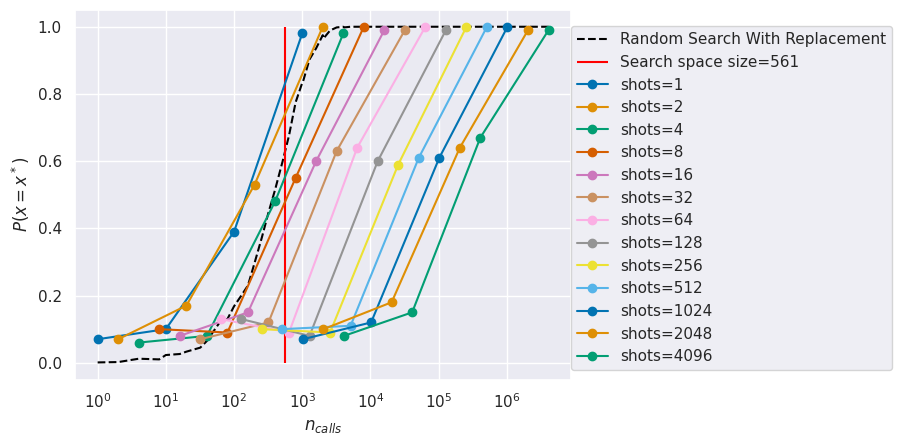

In [11]:
fig, ax = plt.subplots()

ax.plot(
    df_rs.n_calls, 
    df_rs.prob_best_answer, 
    linestyle="--", 
    color="black", 
    label="Random Search With Replacement"
)
ax.vlines(
    x=len(search_space), 
    ymin=0, 
    ymax=1, 
    color="red", 
    label=f"Search space size={len(search_space)}"
)
for idx, n_shots in enumerate([2**i for i in range(13)]):
    df = pd.read_pickle(
        filepath_or_buffer=f"../experiments/scenarioI/results/optuna/CMA-ES_n_shots_{n_shots}_experiments.pkl"
    )
    df["n_calls"] = df.n_shots*df.n_iter
    mask = df.target_probability_after_training > 0
    ax.plot(
        df.n_calls.unique(), 
        (df[mask].groupby("n_calls").target_probability_after_training.count()/100).values,
        label=f"shots={n_shots}",
        marker="o",
        color=colors[idx]
    )
ax.set_xscale("log")
ax.legend(loc=[1,0.025])
ax.set_xlabel(r"$n_{calls}$")
ax.set_ylabel(r"$P(x=x^*)$")

plt.show()

## Scenario II

In [12]:
with open(file="../experiments/scenarioII/scenario_info.pkl", mode="rb") as f:
    scenario_info = pickle.load(f)

In [13]:
answer_bitstring = scenario_info["target"]

In [14]:
n = len(answer_bitstring)
k_min = 3
k_max = 6

In [15]:
search_space = []

for i in range(k_min, k_max+1):

    qc = DickeStateAnsatz().generate_quantum_circuit(n=n, k=i, measurement=False)
    qc = qc.assign_parameters(parameters=(np.pi/2)*np.ones(qc.num_parameters))
    sv = Statevector(qc)
    search_space.extend(list(sv.probabilities_dict().keys()))

In [16]:
len(search_space) == sum([scipy.special.comb(n,i) for i in range(k_min, k_max+1)])

np.True_

In [17]:
try:
    df_rs = pd.read_pickle(filepath_or_buffer="../experiments/scenarioII/df_rs.pkl")
except:
    m = 1000
    columns = ["n_calls", "prob_best_answer"]
    data = []

    for calls in n_calls:
        counter = 0
        for _ in range(m):
            sample = np.random.choice(search_space, size=calls, replace=True)
            if answer_bitstring in sample:
                counter += 1
        data.append([calls, counter/m])
    df_rs = pd.DataFrame(data=data, columns=columns)
    df_rs.to_pickle("../experiments/scenarioII/df_rs.pkl")

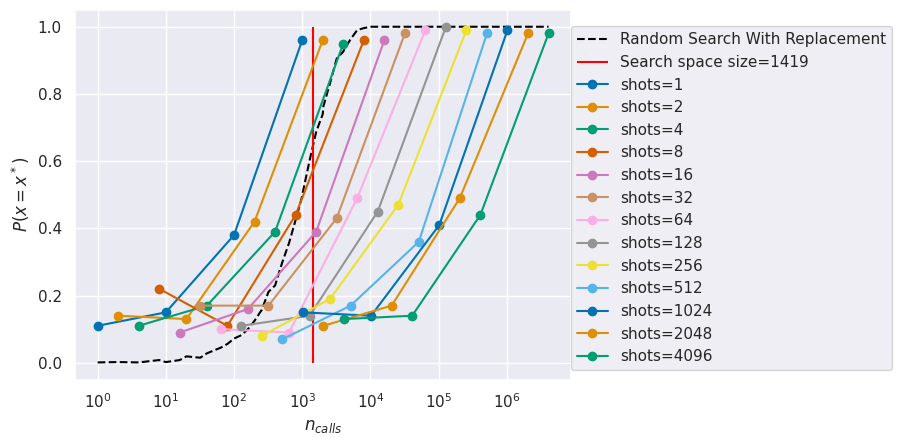

In [18]:
fig, ax = plt.subplots()

ax.plot(
    df_rs.n_calls, 
    df_rs.prob_best_answer, 
    linestyle="--", 
    color="black", 
    label="Random Search With Replacement"
)
ax.vlines(
    x=len(search_space), 
    ymin=0, 
    ymax=1, 
    color="red", 
    label=f"Search space size={len(search_space)}"
)
for idx, n_shots in enumerate([2**i for i in range(13)]):
    df = pd.read_pickle(
        filepath_or_buffer=f"../experiments/scenarioII/results/optuna/CMA-ES_n_shots_{n_shots}_experiments.pkl"
    )
    df["n_calls"] = df.n_shots*df.n_iter
    mask = df.target_probability_after_training > 0
    ax.plot(
        df.n_calls.unique(), 
        (df[mask].groupby("n_calls").target_probability_after_training.count()/100).values,
        label=f"shots={n_shots}",
        marker="o",
        color=colors[idx]
    )
ax.set_xscale("log")
ax.legend(loc=[1,0.025])
ax.set_xlabel(r"$n_{calls}$")
ax.set_ylabel(r"$P(x=x^*)$")

plt.show()

## Scenario III

In [19]:
with open(file="../experiments/scenarioIII/scenario_info.pkl", mode="rb") as f:
    scenario_info = pickle.load(f)

In [20]:
answer_bitstring = scenario_info["target"]

In [21]:
constraints_dict = {
    "Energy": ("eq", 3),
    "Financial Services": ("gleq", 1, 2),
    "Real Estate": ("eq", 2),
    "Basic Materials": ("leq", 4),
}

# Energy
qc = DickeStateAnsatz().generate_quantum_circuit(n=5, k=3, measurement=False)
qc = qc.assign_parameters(parameters=(np.pi/2)*np.ones(qc.num_parameters))
sv = Statevector(qc)
energy_bitstrings = list(sv.probabilities_dict().keys())

# Financial Services
financial_bitstrings = []
for i in range(1, 3):

    qc = DickeStateAnsatz().generate_quantum_circuit(n=5, k=i, measurement=False)
    qc = qc.assign_parameters(parameters=(np.pi/2)*np.ones(qc.num_parameters))
    sv = Statevector(qc)
    financial_bitstrings.extend(list(sv.probabilities_dict().keys()))

# Real Estate
qc = DickeStateAnsatz().generate_quantum_circuit(n=5, k=2, measurement=False)
qc = qc.assign_parameters(parameters=(np.pi/2)*np.ones(qc.num_parameters))
sv = Statevector(qc)
real_estate_bitstrings = list(sv.probabilities_dict().keys())

# Basic Materials
basic_materials_bitstrings = []
for i in range(1, 5):

    qc = DickeStateAnsatz().generate_quantum_circuit(n=5, k=i, measurement=False)
    qc = qc.assign_parameters(parameters=(np.pi/2)*np.ones(qc.num_parameters))
    sv = Statevector(qc)
    basic_materials_bitstrings.extend(list(sv.probabilities_dict().keys()))


search_space = [bit1+bit2+bit3+bit4 for bit1 in energy_bitstrings for bit2 in financial_bitstrings for bit3 in real_estate_bitstrings for bit4 in basic_materials_bitstrings]
search_space = [bitstring[::-1] for bitstring in search_space]

In [22]:
len(search_space) == len(energy_bitstrings)*len(financial_bitstrings)*len(real_estate_bitstrings)*len(basic_materials_bitstrings)

True

In [23]:
try:
    df_rs = pd.read_pickle(filepath_or_buffer="../experiments/scenarioIII/df_rs.pkl")
except:
    m = 1000
    columns = ["n_calls", "prob_best_answer"]
    data = []

    for calls in n_calls:
        counter = 0
        for _ in range(m):
            sample = np.random.choice(search_space, size=calls, replace=True)
            if answer_bitstring in sample:
                counter += 1
        data.append([calls, counter/m])
    df_rs = pd.DataFrame(data=data, columns=columns)
    df_rs.to_pickle("../experiments/scenarioIII/df_rs.pkl")

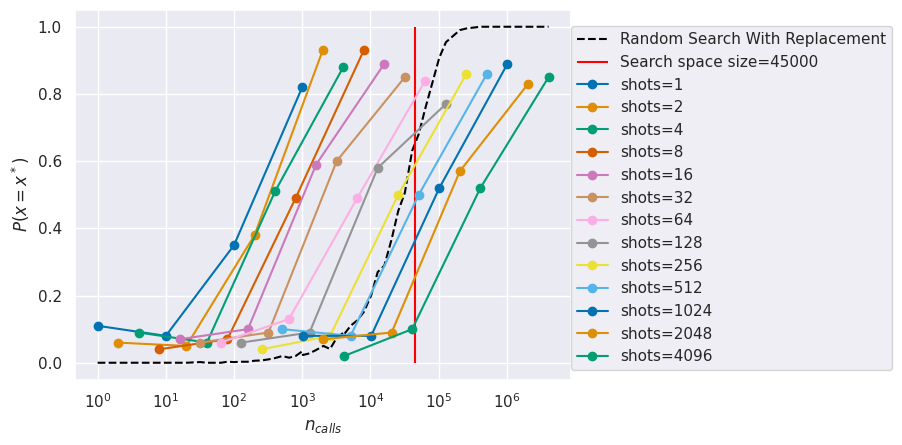

In [24]:
fig, ax = plt.subplots()

ax.plot(
    df_rs.n_calls, 
    df_rs.prob_best_answer, 
    linestyle="--", 
    color="black", 
    label="Random Search With Replacement"
)
ax.vlines(
    x=len(search_space), 
    ymin=0, 
    ymax=1, 
    color="red", 
    label=f"Search space size={len(search_space)}"
)
for idx, n_shots in enumerate([2**i for i in range(13)]):
    df = pd.read_pickle(
        filepath_or_buffer=f"../experiments/scenarioIII/results/optuna/CMA-ES_n_shots_{n_shots}_experiments.pkl"
    )
    df["n_calls"] = df.n_shots*df.n_iter
    mask = df.target_probability_after_training > 0
    ax.plot(
        df.n_calls.unique(), 
        (df[mask].groupby("n_calls").target_probability_after_training.count()/100).values,
        label=f"shots={n_shots}",
        marker="o",
        color=colors[idx]
    )
ax.set_xscale("log")
ax.legend(loc=[1,0.025])
ax.set_xlabel(r"$n_{calls}$")
ax.set_ylabel(r"$P(x=x^*)$")

plt.show()